In [105]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset directory
DATASET_DIR = Path("/Users/nedamohseni/Downloads/SoLo_dataset")

In [111]:
hrv_dfs = []

for participant_dir in sorted(DATASET_DIR.iterdir()):
    if not participant_dir.is_dir():
        continue

    hrv_file = participant_dir / "Samsung" / "hrv_features_5min.csv"

    if not hrv_file.exists():
        print(f"Missing HRV file: {participant_dir.name}")
        continue

    df = pd.read_csv(hrv_file)
    df["participant"] = participant_dir.name
    hrv_dfs.append(df)

hrv_df = pd.concat(hrv_dfs, ignore_index=True)

print("Participants loaded:", hrv_df["participant"].nunique())
print("Total HRV rows:", len(hrv_df))
print("\nColumns:")
print(hrv_df.columns.tolist())

hrv_df

Missing HRV file: pers2037
Missing HRV file: pers2038
Participants loaded: 29
Total HRV rows: 8699

Columns:
['participant', 'timestamp', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2', 'HRV_SDNNI2', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_HTI', 'HRV_TINN', 'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_LFHF', 'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2', 'HRV_S', 'HR']


,participant,timestamp,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_RMSSD,HRV_SDSD,...,HRV_VHF,HRV_LFHF,HRV_LFn,HRV_HFn,HRV_LnHF,HRV_SD1,HRV_SD2,HRV_SD1SD2,HRV_S,HR
0,pers2001,1636800347647,1168.529412,52.471347,5.414991,52.210333,NaN,NaN,47.837076,47.931116,...,0.000685,1.113780,0.522690,0.469294,-3.215756,33.892417,66.138195,0.512448,7042.141682,51.2
1,pers2001,1636800347647,1197.278226,77.375675,17.682430,72.558239,NaN,NaN,66.220250,66.306247,...,0.000554,1.421053,0.578237,0.406907,-4.187971,46.885597,88.228306,0.531412,12995.627735,49.8
2,pers2001,1636807548319,1141.923077,346.636004,50.774081,232.121140,NaN,NaN,458.589200,459.469099,...,0.000197,7.161886,0.875212,0.122204,-4.678377,324.893716,366.603812,0.886226,374186.539188,52.2
3,pers2001,1636807548319,1224.077869,127.864987,41.018396,122.538700,NaN,NaN,82.449012,82.617577,...,0.000157,4.444409,0.813113,0.182952,-4.918855,58.419449,171.428320,0.340781,31462.258682,49.0
4,pers2001,1636814748400,1027.586207,148.863170,101.102659,94.877714,NaN,NaN,113.244843,113.430554,...,0.000770,1.220487,0.528034,0.432642,-4.771074,80.207514,194.094532,0.413239,48907.811619,58.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8694,pers2036,1643536891831,1068.750000,43.546313,7.342531,43.356241,NaN,NaN,52.192091,52.285877,...,0.004993,0.481052,0.306402,0.636942,-2.880122,36.971698,49.386400,0.748621,5736.231166,56.2
8695,pers2036,1643536891831,1056.625442,40.033333,8.361535,38.802103,NaN,NaN,48.217335,48.302973,...,0.005690,0.405671,0.268797,0.662599,-2.901226,34.155360,45.019313,0.758682,4830.672474,56.8
8696,pers2036,1644645730815,842.584746,77.219931,20.251649,74.949294,NaN,NaN,69.179223,69.277383,...,0.002704,1.135988,0.517079,0.455180,-3.115343,48.986507,97.067530,0.504664,14938.270712,71.0
8697,pers2036,1644904942785,937.460815,55.260767,16.894874,52.688329,NaN,NaN,49.506210,49.584171,...,0.001374,0.956284,0.475140,0.496861,-3.713866,35.061304,69.946724,0.501257,7704.515111,64.0


# Pooled Statistics

In [121]:
hrv_features = [c for c in hrv_df.columns if c not in ["participant", "timestamp"]]
hrv_clean = hrv_df[hrv_features].replace([np.inf, -np.inf], np.nan)

pooled_stats = hrv_clean.agg(["count", "mean", "std", "min", "median", "max"]).T
pooled_stats["Q1"] = hrv_clean.quantile(0.25)
pooled_stats["Q3"] = hrv_clean.quantile(0.75)
pooled_stats["IQR"] = pooled_stats["Q3"] - pooled_stats["Q1"]
pooled_stats["lower_fence"] = pooled_stats["Q1"] - 1.5 * pooled_stats["IQR"]
pooled_stats["upper_fence"] = pooled_stats["Q3"] + 1.5 * pooled_stats["IQR"]

pooled_stats["n_outside"] = [((hrv_clean[c] < pooled_stats.loc[c, "lower_fence"]) | (hrv_clean[c] > pooled_stats.loc[c, "upper_fence"])).sum() for c in hrv_features]
pooled_stats["%_outside"] = pooled_stats["n_outside"] / pooled_stats["count"] * 100

pooled_stats = pooled_stats[["count", "mean", "std", "min", "Q1", "median", "Q3", "IQR", "max", "lower_fence", "upper_fence", "n_outside", "%_outside"]]
display(pooled_stats.round(3))

,count,mean,std,min,Q1,median,Q3,IQR,max,lower_fence,upper_fence,n_outside,%_outside
HRV_MeanNN,8699.0,1195.466,2.701240e+02,667.841,1065.357,1183.433,1319.401,254.044,1.747353e+04,684.291,1700.468,40,0.460
HRV_SDNN,8699.0,124.895,3.476380e+02,17.422,65.246,89.255,123.409,58.163,1.877989e+04,-21.998,210.653,401,4.610
HRV_SDANN1,8698.0,43.500,4.289080e+02,0.894,14.006,22.085,38.923,24.917,3.050013e+04,-23.370,76.299,656,7.542
HRV_SDNNI1,8698.0,110.652,3.242710e+02,16.994,60.097,80.869,110.982,50.886,1.751175e+04,-16.232,187.311,324,3.725
HRV_SDANN2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
HRV_SDNNI2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
HRV_RMSSD,8699.0,136.884,4.880790e+02,21.706,61.711,87.528,125.590,63.878,2.683040e+04,-34.106,221.407,430,4.943
HRV_SDSD,8699.0,137.300,4.948820e+02,21.739,61.823,87.723,125.878,64.055,2.756834e+04,-34.260,221.961,430,4.943
HRV_CVNN,8699.0,0.096,1.230000e-01,0.019,0.055,0.075,0.103,0.048,2.656000e+00,-0.017,0.176,352,4.046
HRV_CVSD,8699.0,0.102,1.660000e-01,0.023,0.054,0.073,0.102,0.048,3.528000e+00,-0.019,0.175,430,4.943


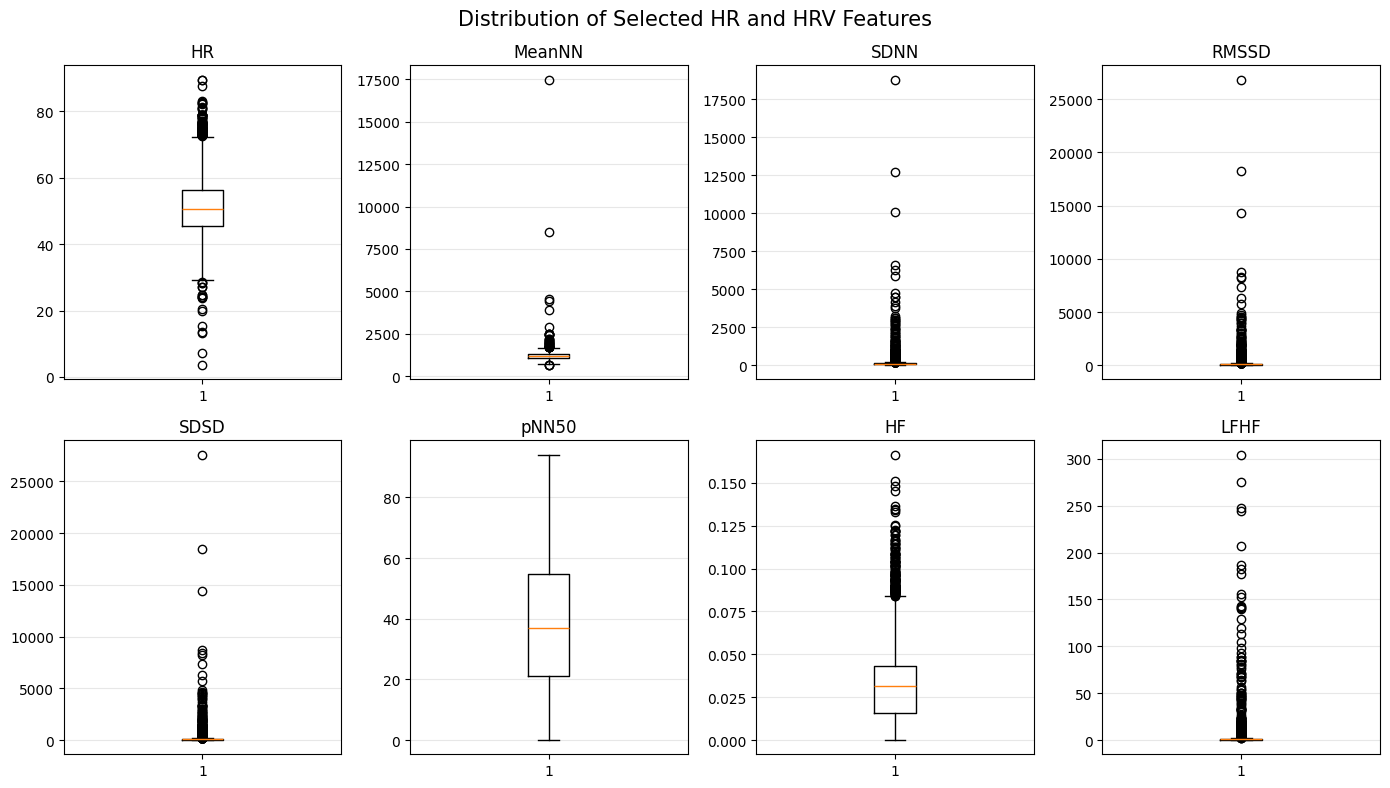

In [126]:
plot_features = ["HR", "HRV_MeanNN", "HRV_SDNN", "HRV_RMSSD", "HRV_SDSD", "HRV_pNN50", "HRV_HF", "HRV_LFHF"]

fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

for ax, feature in zip(axes, plot_features):
    values = hrv_clean[feature].dropna()
    ax.boxplot(values)
    ax.set_title(feature.replace("HRV_", ""))
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Distribution of Selected HR and HRV Features", fontsize=15)
plt.tight_layout()
plt.show()

# Participant-Aggregated Statistics

In [128]:
participant_means = hrv_df.groupby("participant")[hrv_features].mean()

participant_stats = participant_means.agg(["count", "mean", "std", "min", "median", "max"]).T
participant_stats["Q1"] = participant_means.quantile(0.25)
participant_stats["Q3"] = participant_means.quantile(0.75)
participant_stats["IQR"] = participant_stats["Q3"] - participant_stats["Q1"]
participant_stats["lower_fence"] = participant_stats["Q1"] - 1.5 * participant_stats["IQR"]
participant_stats["upper_fence"] = participant_stats["Q3"] + 1.5 * participant_stats["IQR"]

participant_stats["n_outside"] = [((participant_means[c] < participant_stats.loc[c, "lower_fence"]) | (participant_means[c] > participant_stats.loc[c, "upper_fence"])).sum() for c in hrv_features]
participant_stats["%_outside"] = participant_stats["n_outside"] / participant_stats["count"] * 100

participant_stats = participant_stats[["count", "mean", "std", "min", "Q1", "median", "Q3", "IQR", "max", "lower_fence", "upper_fence", "n_outside", "%_outside"]]

display(participant_stats.round(3))

,count,mean,std,min,Q1,median,Q3,IQR,max,lower_fence,upper_fence,n_outside,%_outside
HRV_MeanNN,29.0,1143.243,130.532,883.377,1057.695,1108.460,1237.897,180.201,1423.216,787.393,1508.199,0,0.000
HRV_SDNN,29.0,107.901,41.320,46.860,83.575,103.084,125.442,41.866,206.983,20.776,188.241,2,6.897
HRV_SDANN1,29.0,35.527,19.230,2.245,24.229,30.592,40.744,16.515,91.514,-0.544,65.517,2,6.897
HRV_SDNNI1,29.0,96.365,36.531,46.783,75.364,88.177,113.399,38.034,182.377,18.313,170.450,2,6.897
HRV_SDANN2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
HRV_SDNNI2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
HRV_RMSSD,29.0,117.874,55.901,49.640,84.352,101.451,134.031,49.679,258.608,9.835,208.549,2,6.897
HRV_SDSD,29.0,118.196,56.160,49.728,84.495,101.927,134.312,49.817,259.350,9.770,209.037,2,6.897
HRV_CVNN,29.0,0.087,0.025,0.040,0.073,0.081,0.095,0.022,0.147,0.040,0.128,4,13.793
HRV_CVSD,29.0,0.093,0.034,0.046,0.072,0.087,0.101,0.029,0.179,0.028,0.145,3,10.345


# selected features

In [132]:
selected_features = ["HR", "HRV_MeanNN", "HRV_SDNN", "HRV_RMSSD", "HRV_SDSD", "HRV_pNN50", "HRV_HF", "HRV_LFHF"]

participant_means = hrv_df.groupby("participant")[selected_features].mean()

participant_stats_selected = participant_means.agg(["count", "mean", "std", "min", "median", "max"]).T
participant_stats_selected["Q1"] = participant_means.quantile(0.25)
participant_stats_selected["Q3"] = participant_means.quantile(0.75)
participant_stats_selected["IQR"] = participant_stats_selected["Q3"] - participant_stats_selected["Q1"]
participant_stats_selected["lower_fence"] = participant_stats_selected["Q1"] - 1.5 * participant_stats_selected["IQR"]
participant_stats_selected["upper_fence"] = participant_stats_selected["Q3"] + 1.5 * participant_stats_selected["IQR"]

participant_stats_selected["n_outside"] = [((participant_means[c] < participant_stats_selected.loc[c, "lower_fence"]) | (participant_means[c] > participant_stats_selected.loc[c, "upper_fence"])).sum() for c in selected_features]
participant_stats_selected["%_outside"] = participant_stats_selected["n_outside"] / participant_stats_selected["count"] * 100

participant_stats_selected = participant_stats_selected[["count", "mean", "std", "min", "Q1", "median", "Q3", "IQR", "max", "lower_fence", "upper_fence", "n_outside", "%_outside"]]

display(participant_stats_selected.round(3))

,count,mean,std,min,Q1,median,Q3,IQR,max,lower_fence,upper_fence,n_outside,%_outside
HR,29.0,53.592,6.094,42.317,48.960,54.613,56.924,7.964,68.346,37.015,68.869,0,0.000
HRV_MeanNN,29.0,1143.243,130.532,883.377,1057.695,1108.460,1237.897,180.201,1423.216,787.393,1508.199,0,0.000
HRV_SDNN,29.0,107.901,41.320,46.860,83.575,103.084,125.442,41.866,206.983,20.776,188.241,2,6.897
HRV_RMSSD,29.0,117.874,55.901,49.640,84.352,101.451,134.031,49.679,258.608,9.835,208.549,2,6.897
HRV_SDSD,29.0,118.196,56.160,49.728,84.495,101.927,134.312,49.817,259.350,9.770,209.037,2,6.897
HRV_pNN50,29.0,34.405,15.962,10.551,24.582,31.686,47.400,22.818,69.765,-9.646,81.628,0,0.000
HRV_HF,29.0,0.035,0.011,0.019,0.027,0.034,0.041,0.014,0.075,0.006,0.062,1,3.448
HRV_LFHF,29.0,1.632,1.215,0.289,0.763,1.288,1.791,1.028,5.272,-0.778,3.333,3,10.345


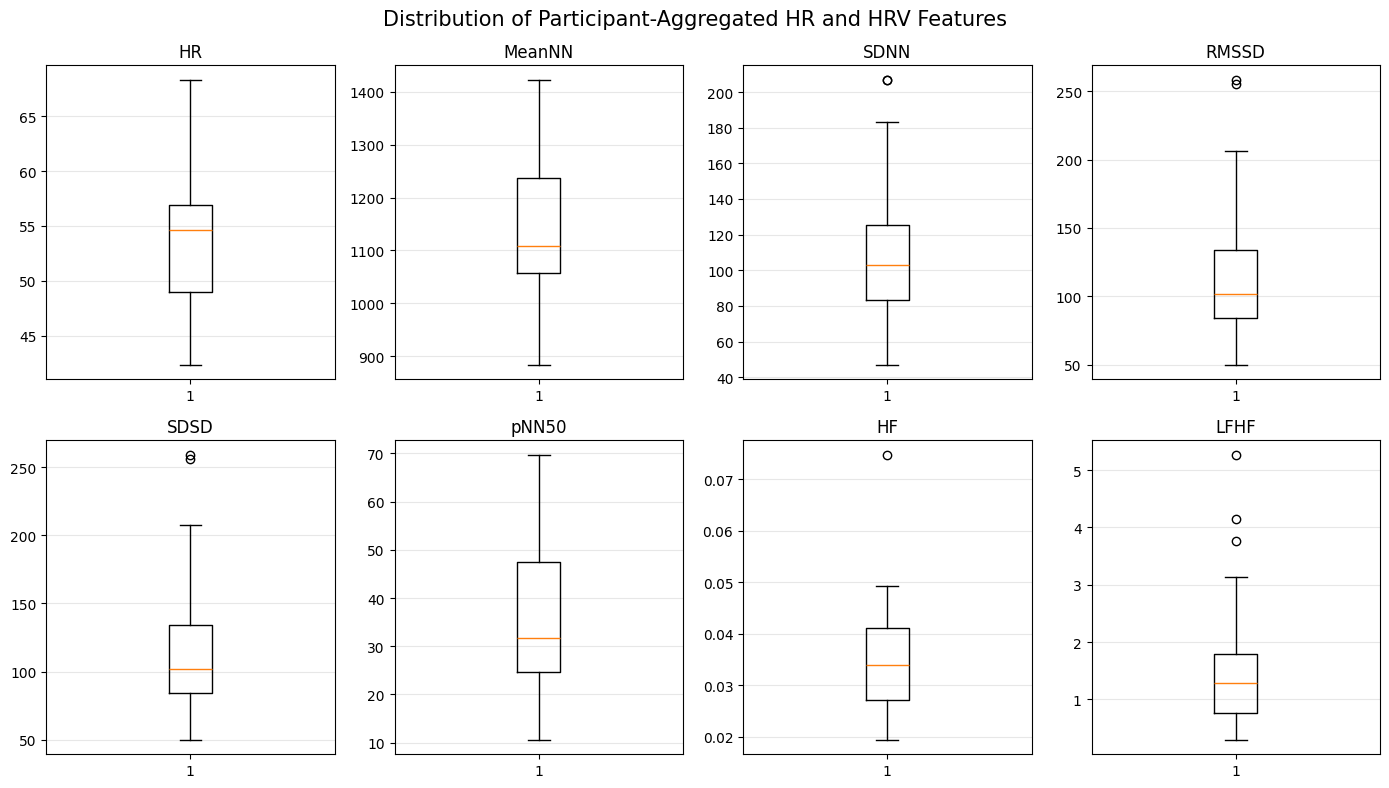

In [134]:
selected_features = ["HR", "HRV_MeanNN", "HRV_SDNN", "HRV_RMSSD", "HRV_SDSD", "HRV_pNN50", "HRV_HF", "HRV_LFHF"]

fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

for ax, feature in zip(axes, selected_features):
    values = participant_means[feature].dropna()
    ax.boxplot(values)
    ax.set_title(feature.replace("HRV_", ""))
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Distribution of Participant-Aggregated HR and HRV Features", fontsize=15)
plt.tight_layout()
plt.show()